In [1]:
import numpy as np 
import pandas as pd
!pip install scikit-learn

## Problem Introduction and Data Ingestion

## Objectives
### To predict the house price from various house atrributes present in the data
### This is a Regression problem

### General steps for a ML workflow (Not an exhaustive or standard list)
### 1. Data Ingestion
### 2. Train Test split
### 3. Data Cleaning
### 4. Feature Extraction
### 5. EDA
### 6. One Hot Encoding
### 7. Feature Scaling
### 8. Feature Selection
### 9. Model Training
### 10. Model Evaluation


### In this session we will mostly focus on Feature Engineering and Feature Scaling aspects of the workflow. Model training and evaluation will be covered later 


## Data Ingestion

In [2]:
# Importing house_price csv data file

In [3]:
house_data=pd.read_csv('D:\dataset\\house_price.csv')
house_data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
house_data.shape

(1460, 81)

In [5]:
house_data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

### Train/Test Split
#### Always remember there will be always a chance of data leakage so we need to split the data first and then apply feature Engineering especially scaling. Data Cleaning, Null Value treatment can still be done on the entire data set since there wont be significant data leakage. But it is always a good practice to treat Test data seperately always.

In [6]:
# Using 75/25 ratio for train test split in this case

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test =train_test_split(house_data.loc[:,house_data.columns!='SalePrice'],
                                               house_data['SalePrice'],test_size=.25,random_state=100)




In [7]:
x_train.shape,x_test.shape

((1095, 80), (365, 80))

### Treating Missing Values
#### Categorical Features

In [8]:
# Extracting a list of categorical fields with missing values
# Note: Categorical fields will have data type as 'o' ,as can be observed innthe filtervcondition below
# o means object

feature_with_missingval=[feature for feature in house_data.columns if house_data[feature].isna().sum()>=1 and house_data[feature].dtype=='O' ]
feature_with_missingval

['Alley',
 'MasVnrType',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [9]:
# Using a list of Categorical fields with missing values
# Categorical fields will have data type 'o' as can be observed the the filter condition below
feature_with_missingval


['Alley',
 'MasVnrType',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [10]:
# printing % of missing values in all categorical features


for feature in feature_with_missingval:
    print('{0}:{1}% missing values'.format(feature,np.round(house_data[feature].isna().mean()*100,2)))

Alley:93.77% missing values
MasVnrType:0.55% missing values
BsmtQual:2.53% missing values
BsmtCond:2.53% missing values
BsmtExposure:2.6% missing values
BsmtFinType1:2.53% missing values
BsmtFinType2:2.6% missing values
Electrical:0.07% missing values
FireplaceQu:47.26% missing values
GarageType:5.55% missing values
GarageFinish:5.55% missing values
GarageQual:5.55% missing values
GarageCond:5.55% missing values
PoolQC:99.52% missing values
Fence:80.75% missing values
MiscFeature:96.3% missing values


In [11]:
## Replacing missing values with a new labeel 'NOT AVAILABLE'

def replace_missing_labels(df,features):
    dataset = df.copy()
    dataset[features]=dataset[features].fillna('Not Availabel')
    return dataset

house_data= replace_missing_labels(house_data,feature_with_missingval)

house_data[feature_with_missingval].isna().sum()  # Print the final count of null

Alley           0
MasVnrType      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
Electrical      0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
PoolQC          0
Fence           0
MiscFeature     0
dtype: int64

## Numeric Features

In [12]:
# Similarly lets check for list of features with numeric values
## for numeric features dtype will not be O

numerical_with_nan=[feature for feature in house_data.columns if house_data[feature].isna().sum()>=1 and house_data[feature].dtype!='O' ]

#Print the numerical variables and percentage of miising values

for feature in numerical_with_nan:
    print('{}:{}% missing value'.format(feature,np.around(house_data[feature].isna().mean(),2)))

LotFrontage:0.18% missing value
MasVnrArea:0.01% missing value
GarageYrBlt:0.06% missing value


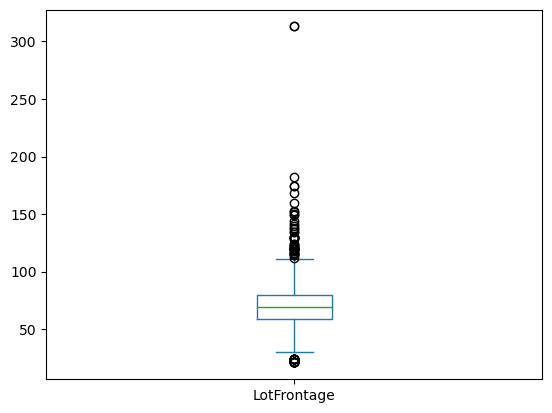

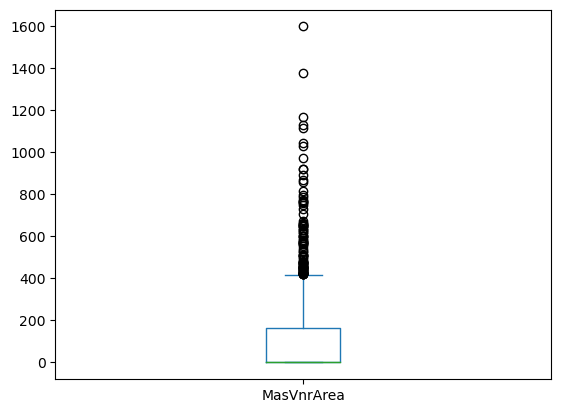

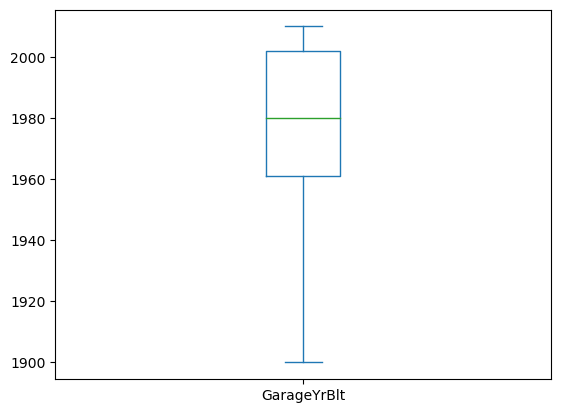

In [13]:
import matplotlib.pyplot as plt
for col in numerical_with_nan:
    house_data[col].plot(kind='box')
    plt.show()

In [14]:
# Imputing missing values with median
## We will replace by using median since there are outliers

for feature in numerical_with_nan:
    house_data[feature].fillna(house_data[feature].median(),inplace=True)

house_data[numerical_with_nan].isna().sum()


        
        

LotFrontage    0
MasVnrArea     0
GarageYrBlt    0
dtype: int64

## Feature Extraction

In [15]:
# The below year based features are not useful for any model
# Hence we can convert them into Duration by subtracting from year sold to determine the age


for feature in['YearBuilt','YearRemodAdd','GarageYrBlt']:
    house_data[feature]=house_data['YrSold']-house_data[feature]

## We can see below how your year based feature have been converted to duration

In [16]:
house_data[['YearBuilt','YearRemodAdd','GarageYrBlt']].head()

,YearBuilt,YearRemodAdd,GarageYrBlt
0,5,5,5.0
1,31,31,31.0
2,7,6,7.0
3,91,36,8.0
4,8,8,8.0


## Handling Rare Categorial Labels inside features


### If a label is occupying less tha 1% of the data in a feature , then we can remove that since that wont be adding any value to any model
### Dropping that label can improve the performance of a model.

In [17]:
# Generating list of Categories variables


categories=[feature for feature in house_data.columns if house_data[feature].dtype=='O']

In [18]:
categories

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Exterior1st',
 'Exterior2nd',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleType',
 'SaleCondition']

In [19]:
# Below code snippet imputes all labels having less than 1% weight in a data to 'insignificant label'


for feature in categories:
    
    
    label_percentage= house_data.groupby(feature)['SalePrice'].count()/len(house_data)
    label_more_than_1_percent =label_percentage[label_percentage >0.01].index
    house_data[feature]=np.where(house_data[feature].isin(label_more_than_1_percent),house_data[feature],'Insignificant Label')

In [20]:
label_percentage

SaleCondition
Abnorml    0.069178
AdjLand    0.002740
Alloca     0.008219
Family     0.013699
Normal     0.820548
Partial    0.085616
Name: SalePrice, dtype: float64

In [21]:
label_more_than_1_percent

Index(['Abnorml', 'Family', 'Normal', 'Partial'], dtype='object', name='SaleCondition')

In [22]:
house_data.groupby('Fence')['SalePrice'].count()/len(house_data)
# label_more_than_1_percent=label_percentage[label_percentage>0.01].index

Fence
GdPrv                  0.040411
GdWo                   0.036986
Insignificant Label    0.007534
MnPrv                  0.107534
Not Availabel          0.807534
Name: SalePrice, dtype: float64

### We confirm that 'insignificant label' is a part of categorical features as below-

In [23]:
house_data.Street.unique()

array(['Pave', 'Insignificant Label'], dtype=object)

## One Hot Encoding

### Since machine based algorythms cant understand words, we usually need to cinvert categorical features into binary ones
### It can be done using pd.get_dummies()function as below

In [24]:
categories_dummy =pd.DataFrame()

for category in categories:
    categories_dummy = pd.concat([categories_dummy,pd.get_dummies(house_data[category],drop_first=True)],axis=1)
categories_dummy.head()    

,Insignificant Label,RH,RL,RM,Pave,Not Availabel,Pave,IR2,Insignificant Label,Reg,...,Not Availabel,Not Availabel,Shed,Insignificant Label,New,WD,Family,Insignificant Label,Normal,Partial
0,0,0,1,0,1,1,0,0,0,1,...,1,1,0,0,0,1,0,0,1,0
1,0,0,1,0,1,1,0,0,0,1,...,1,1,0,0,0,1,0,0,1,0
2,0,0,1,0,1,1,0,0,0,0,...,1,1,0,0,0,1,0,0,1,0
3,0,0,1,0,1,1,0,0,0,0,...,1,1,0,0,0,1,0,0,0,0
4,0,0,1,0,1,1,0,0,0,0,...,1,1,0,0,0,1,0,0,1,0


## Once the dummies are created , insignificant labels cab be dropped as below-

In [25]:
categories_dummy.drop(['Insignificant Label','Not Availabel'],axis=1,inplace=True)
categories_dummy

,RH,RL,RM,Pave,Pave,IR2,Reg,HLS,Low,Lvl,...,P,Y,GdWo,MnPrv,Shed,New,WD,Family,Normal,Partial
0,0,1,0,1,0,0,1,0,0,1,...,0,1,0,0,0,0,1,0,1,0
1,0,1,0,1,0,0,1,0,0,1,...,0,1,0,0,0,0,1,0,1,0
2,0,1,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,1,0,1,0
3,0,1,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,1,0,0,0
4,0,1,0,1,0,0,0,0,0,1,...,0,1,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0,1,0,1,0,0,1,0,0,1,...,0,1,0,0,0,0,1,0,1,0
1456,0,1,0,1,0,0,1,0,0,1,...,0,1,0,1,0,0,1,0,1,0
1457,0,1,0,1,0,0,1,0,0,1,...,0,1,0,0,1,0,1,0,1,0
1458,0,1,0,1,0,0,1,0,0,1,...,0,1,0,0,0,0,1,0,1,0


### Before the dummies are merged with the main data, all the categorical fields are droped since those are no longer required

In [26]:
for feature in house_data.columns:
    if house_data[feature].dtype=='O':
        house_data.drop([feature],axis=1,inplace=True)
house_data

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,5,5,196.0,706,...,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,31,31,0.0,978,...,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,7,6,162.0,486,...,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,91,36,0.0,216,...,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,8,8,350.0,655,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,8,7,0.0,0,...,0,40,0,0,0,0,0,8,2007,175000
1456,1457,20,85.0,13175,6,6,32,22,119.0,790,...,349,0,0,0,0,0,0,2,2010,210000
1457,1458,70,66.0,9042,7,9,69,4,0.0,275,...,0,60,0,0,0,0,2500,5,2010,266500
1458,1459,20,68.0,9717,5,6,60,14,0.0,49,...,366,0,112,0,0,0,0,4,2010,142125


### Finally dummies are merged with main data

In [27]:
house_data = pd.concat([house_data,categories_dummy],axis=1)
house_data


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,P,Y,GdWo,MnPrv,Shed,New,WD,Family,Normal,Partial
0,1,60,65.0,8450,7,5,5,5,196.0,706,...,0,1,0,0,0,0,1,0,1,0
1,2,20,80.0,9600,6,8,31,31,0.0,978,...,0,1,0,0,0,0,1,0,1,0
2,3,60,68.0,11250,7,5,7,6,162.0,486,...,0,1,0,0,0,0,1,0,1,0
3,4,70,60.0,9550,7,5,91,36,0.0,216,...,0,1,0,0,0,0,1,0,0,0
4,5,60,84.0,14260,8,5,8,8,350.0,655,...,0,1,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,62.0,7917,6,5,8,7,0.0,0,...,0,1,0,0,0,0,1,0,1,0
1456,1457,20,85.0,13175,6,6,32,22,119.0,790,...,0,1,0,1,0,0,1,0,1,0
1457,1458,70,66.0,9042,7,9,69,4,0.0,275,...,0,1,0,0,1,0,1,0,1,0
1458,1459,20,68.0,9717,5,6,60,14,0.0,49,...,0,1,0,0,0,0,1,0,1,0


## Feature Scaling

In [28]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test =train_test_split(house_data.loc[:,house_data.columns!='SalePrice'],
                                               house_data['SalePrice'],test_size=.25,random_state=100)

In [29]:
x_train.shape,x_test.shape

((1095, 166), (365, 166))

## Id is not a useful feature and SalePrice is our target variable. Hence those are removed from the data to be scaled

In [30]:

l1= list(categories_dummy.columns)
l1.extend(['Id','SalePrice'])

In [31]:
features_to_be_scaled =[feature for feature in x_train.columns if feature not in l1]
# since along with Id and SalePrice all are OneHot Encoded variables must be excluded in scaling

In [32]:



features_to_be_scaled =[feature for feature in x_train.columns if feature not in l1 =[feature for feature in x_train.columns if feature not in l1]

SyntaxError: invalid syntax (963887402.py, line 1)

In [33]:
features_to_be_scaled 

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

## Normalisation Scaling

In [34]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
x_train_normalised = scaler_minmax.fit_transform(x_train[features_to_be_scaled])
x_test_normalised = scaler_minmax.transform(x_test[features_to_be_scaled])

In [35]:
x_train_normalised

array([[0.        , 0.30479452, 0.0604174 , ..., 0.        , 0.54545455,
        0.25      ],
       [0.05882353, 0.20205479, 0.05636963, ..., 0.        , 0.63636364,
        0.75      ],
       [0.38235294, 0.16438356, 0.02916637, ..., 0.        , 0.45454545,
        0.25      ],
       ...,
       [0.58823529, 0.1609589 , 0.03047512, ..., 0.        , 1.        ,
        0.25      ],
       [0.17647059, 0.13356164, 0.04272126, ..., 0.        , 0.36363636,
        0.75      ],
       [0.23529412, 0.24315068, 0.04029073, ..., 0.        , 0.45454545,
        0.25      ]])

## Standardisation Scaling

In [36]:
from sklearn.preprocessing import StandardScaler

sc= StandardScaler()
x_train_standardised = sc.fit_transform(x_train[features_to_be_scaled])
x_test_standardised = sc.transform(x_test[features_to_be_scaled])

In [37]:
x_train_standardised

array([[-0.88709814,  1.83446905,  0.37428682, ..., -0.08307923,
         0.24587152, -0.6128851 ],
       [-0.65255209,  0.46567996,  0.28767647, ..., -0.08307923,
         0.60871426,  0.88345644],
       [ 0.63745118, -0.03620937, -0.29439307, ..., -0.08307923,
        -0.11697122, -0.6128851 ],
       ...,
       [ 1.45836235, -0.08183567, -0.26638973, ..., -0.08307923,
         2.06008523, -0.6128851 ],
       [-0.18345999, -0.44684609, -0.00435842, ..., -0.08307923,
        -0.47981396,  0.88345644],
       [ 0.05108606,  1.0131956 , -0.05636463, ..., -0.08307923,
        -0.11697122, -0.6128851 ]])

In [38]:
print('mean of x_train is : ' +str(x_train_standardised.mean()))
print('Standard Deviation of x_train is : ' +str(x_train_standardised.std()))
print('mean of x_test is : '+str(x_test_standardised.mean()))
print('Standard Deviation of x_test is : '+str(x_test_standardised.std()))

mean of x_train is : 2.003448424690904e-15
Standard Deviation of x_train is : 0.9999999999999999
mean of x_test is : -0.01263286504082514
Standard Deviation of x_test is : 1.0054572703595637


In [39]:

print('mean of x_test is : ' +str(x_test_standardised.mean()))
print('Standard Deviation of x_test is : ' +str(x_test_standardised.std()))

mean of x_test is : -0.01263286504082514
Standard Deviation of x_test is : 1.0054572703595637


In [40]:
# transform the train and test set, and add on the Id ans SalePrice variables

x_train =pd.DataFrame(x_train_normalised)

x_test =pd.DataFrame(x_test_normalised)

In [41]:
x_train

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,0.000000,0.304795,0.060417,0.777778,0.500,0.007353,0.032787,0.234375,0.000000,0.0,...,0.631171,0.367561,0.086042,0.000000,0.000000,0.000000,0.0,0.0,0.545455,0.25
1,0.058824,0.202055,0.056370,0.444444,0.750,0.647059,0.065574,0.000000,0.126329,0.0,...,0.304654,0.000000,0.000000,0.079710,0.000000,0.000000,0.0,0.0,0.636364,0.75
2,0.382353,0.164384,0.029166,0.555556,0.625,0.213235,0.491803,0.000000,0.136960,0.0,...,0.331453,0.000000,0.000000,0.000000,0.000000,0.513369,0.0,0.0,0.454545,0.25
3,0.235294,0.184932,0.037743,0.666667,0.500,0.044118,0.098361,0.000000,0.000000,0.0,...,0.433709,0.212369,0.347992,0.000000,0.000000,0.000000,0.0,0.0,0.909091,0.75
4,0.176471,0.167808,0.034761,0.555556,0.750,0.617647,0.950820,0.000000,0.053154,0.0,...,0.310296,0.000000,0.072658,0.000000,0.283465,0.000000,0.0,0.0,0.363636,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1090,0.235294,0.143836,0.032247,0.666667,0.500,0.022059,0.065574,0.000000,0.114812,0.0,...,0.289140,0.042007,0.034417,0.000000,0.000000,0.000000,0.0,0.0,0.818182,0.50
1091,0.000000,0.160959,0.228895,0.888889,0.500,0.183824,0.327869,0.000000,0.320695,0.0,...,0.630465,1.000000,0.137667,0.000000,0.000000,0.000000,0.0,0.0,0.909091,0.00
1092,0.588235,0.160959,0.030475,0.888889,0.500,0.000000,0.016393,0.226250,0.000000,0.0,...,0.435120,0.245041,0.103250,0.000000,0.000000,0.000000,0.0,0.0,1.000000,0.25
1093,0.176471,0.133562,0.042721,0.444444,0.625,0.727941,0.475410,0.000000,0.000000,0.0,...,0.310296,0.086348,0.000000,0.231884,0.000000,0.000000,0.0,0.0,0.363636,0.75


In [42]:
x_test

,0,1,2,3,4,5,6,7,8,9,...,26,27,28,29,30,31,32,33,34,35
0,0.000000,0.133562,0.035991,0.333333,0.625,0.264706,0.606557,0.00000,0.109142,0.000000,...,0.372355,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.363636,0.25
1,0.235294,0.232877,0.048354,0.666667,0.500,0.014706,0.049180,0.00000,0.000000,0.000000,...,0.398449,0.000000,0.133843,0.0,0.0,0.0,0.000000,0.0,0.636364,0.00
2,0.000000,0.143836,0.030732,0.666667,0.500,0.088235,0.196721,0.02375,0.000000,0.000000,...,0.283498,0.256709,0.040153,0.0,0.0,0.0,0.000000,0.0,0.454545,0.25
3,0.235294,0.198630,0.037136,0.666667,0.500,0.007353,0.032787,0.00000,0.000000,0.000000,...,0.450635,0.168028,0.101338,0.0,0.0,0.0,0.000000,0.0,0.272727,0.25
4,0.352941,0.188356,0.040104,0.555556,0.625,0.227941,0.524590,0.00000,0.092488,0.000000,...,0.252468,0.236873,0.000000,0.0,0.0,0.0,0.888889,0.0,0.545455,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,0.058824,0.133562,0.035836,0.444444,0.125,0.639706,0.950820,0.00000,0.000000,0.000000,...,0.238364,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.909091,0.25
361,1.000000,0.140411,0.041160,0.444444,0.750,0.500000,0.163934,0.00000,0.062190,0.122795,...,0.000000,0.163361,0.000000,0.0,0.0,0.0,0.000000,0.0,0.727273,0.50
362,0.000000,0.075342,0.057342,0.444444,0.500,0.080882,0.196721,0.00000,0.126860,0.000000,...,0.406206,0.261377,0.000000,0.0,0.0,0.0,0.000000,0.0,0.545455,0.00
363,0.000000,0.133562,0.027577,0.444444,0.875,0.419118,0.098361,0.00000,0.070517,0.101085,...,0.507757,0.226371,0.000000,0.0,0.0,0.0,0.000000,0.0,0.545455,0.25


# Feature Engineering Casre 2 | Titanic Data

## problem Introduction and Data Ingestion 

## Objective

### To predict whether the given person survived in titanic mishap or not.
### This is a very famous example of Classification problem.

## Data Ingestion

### Titanic classification problem data is a standard dataset used for many mock ML case studies. It can be loaded from Seaborn library as an inbuilt data set.


In [44]:

titanic =pd.read_csv('D:\dataset\\titanic.csv')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,deck
0,0,3,male,22.0,1,0,7.2500,S,NaN
1,1,1,female,38.0,1,0,71.2833,C,C
2,1,3,female,26.0,0,0,7.9250,S,NaN
3,1,1,female,35.0,1,0,53.1000,S,C
4,0,3,male,35.0,0,0,8.0500,S,NaN


## Feature Extraction & EDA

In [45]:
## Checking if the data has missing values if yes, Which features


titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   deck      203 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 62.8+ KB


## Analysing if Priority Class had any impact on Survival Rate

In [46]:
print(titanic[['pclass','survived']].groupby(['pclass'],as_index=False).mean())

   pclass  survived
0       1  0.629630
1       2  0.472826
2       3  0.242363


### Insights:
### yes, Passengers having high priority class had better survival rate

## Analysing if family size had any impact on Survival Rate.
### Family size is not available to us directly in the data but we have Parent/Children and Sibling /spouse feature. By adding all we can get family size which can be a useful feature as below:


In [49]:
titanic['FamilySize']= titanic['sibsp']+titanic['parch']+1
print(titanic[['FamilySize','survived']].groupby(['FamilySize'],as_index=False).mean())

   FamilySize  survived
0           1  0.303538
1           2  0.552795
2           3  0.578431
3           4  0.724138
4           5  0.200000
5           6  0.136364
6           7  0.333333
7           8  0.000000
8          11  0.000000


### Insights:
### These seems to be a pattern here with moderately sized families standing a better survival chance

### Analysing if Gender had any impact on Survival Rate

In [50]:
print(titanic[['sex','survived']].groupby(['sex'],as_index=False).mean())

      sex  survived
0  female  0.742038
1    male  0.188908


### Analysing if Base city of passengers had any impact on Survival Rate.

In [51]:
titanic['embarked']=titanic['survived'].fillna(titanic['embarked'].mode[0])
print(titanic[['embarked','survived']].groupby(['embarked'],as_index=False).mean())

TypeError: 'method' object is not subscriptable